# 2. EDA & Statistical Testing
**Chặng bay:** Delhi → Cochin  
**Mục tiêu:** Cung cấp minh chứng thống kê cho báo cáo và slide thuyết trình.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv("master_data_merged.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(f"Shape: {df.shape}")
df.head()

Shape: (37, 4)


,Date,Median_Price,Brent_Oil_Price,USD_INR_Exchange
0,2019-03-01,23533.0,65.070000,70.816002
1,2019-03-03,14973.0,65.070000,70.816002
2,2019-03-06,15078.0,65.989998,70.742500
3,2019-03-09,13843.0,65.739998,70.487503
4,2019-03-15,5784.5,67.160004,69.337303


## 1. Visualisation – 3 chuỗi thời gian trên cùng trục

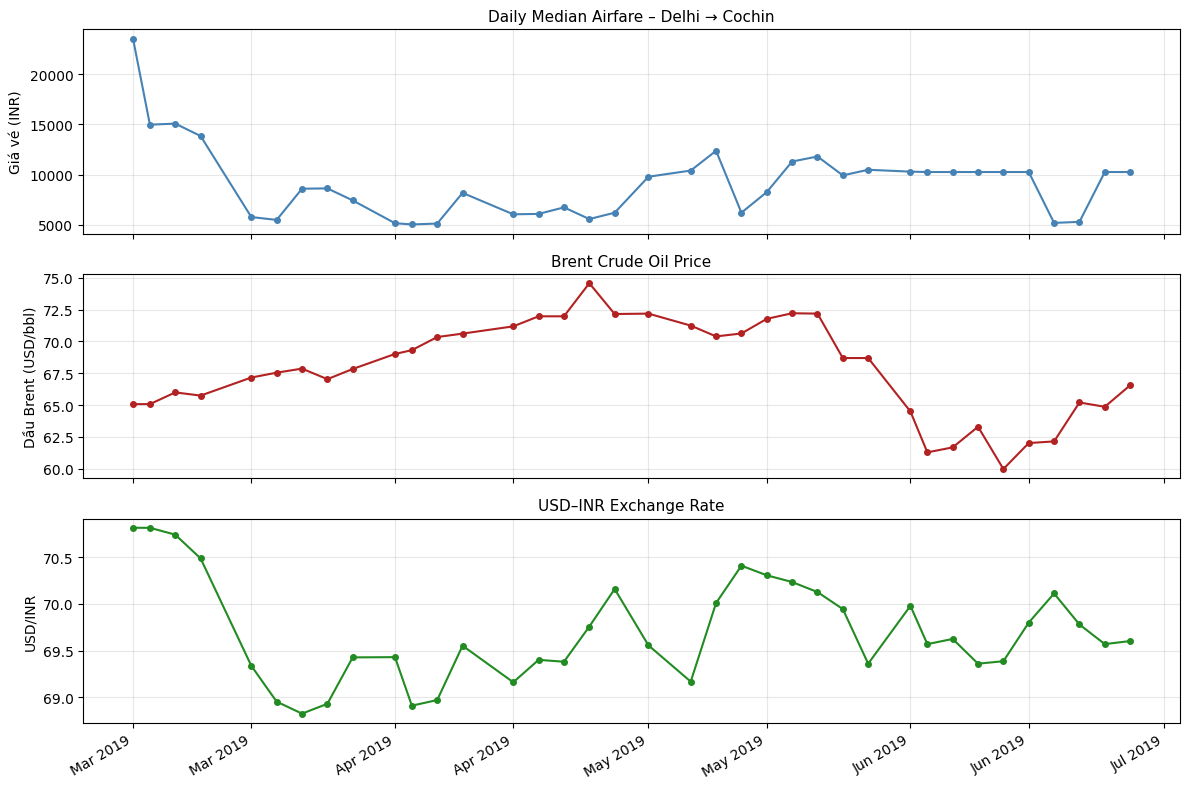

Đã lưu biểu đồ: eda_timeseries.png


In [2]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df["Date"], df["Median_Price"], color="steelblue", marker="o", markersize=4)
axes[0].set_ylabel("Giá vé (INR)", fontsize=10)
axes[0].set_title("Daily Median Airfare – Delhi → Cochin", fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["Date"], df["Brent_Oil_Price"], color="firebrick", marker="o", markersize=4)
axes[1].set_ylabel("Dầu Brent (USD/bbl)", fontsize=10)
axes[1].set_title("Brent Crude Oil Price", fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(df["Date"], df["USD_INR_Exchange"], color="forestgreen", marker="o", markersize=4)
axes[2].set_ylabel("USD/INR", fontsize=10)
axes[2].set_title("USD–INR Exchange Rate", fontsize=11)
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()

plt.tight_layout()
plt.savefig("eda_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu biểu đồ: eda_timeseries.png")

## 2. Ma trận tương quan (Pearson Correlation)

Pearson Correlation Matrix:
                  Median_Price  Brent_Oil_Price  USD_INR_Exchange
Median_Price            1.0000          -0.2976            0.6001
Brent_Oil_Price        -0.2976           1.0000           -0.0783
USD_INR_Exchange        0.6001          -0.0783            1.0000


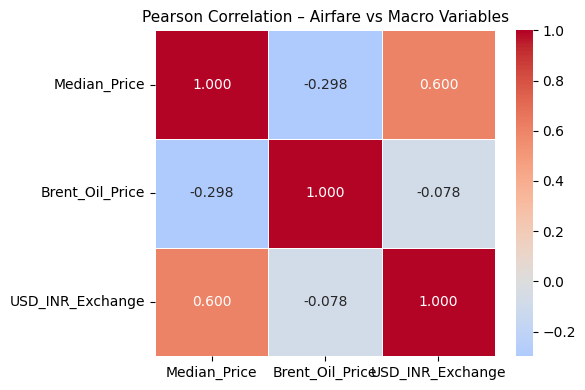

Đã lưu biểu đồ: eda_correlation.png


In [3]:
import seaborn as sns

corr = df[["Median_Price", "Brent_Oil_Price", "USD_INR_Exchange"]].corr()
print("Pearson Correlation Matrix:")
print(corr.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation – Airfare vs Macro Variables", fontsize=11)
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu biểu đồ: eda_correlation.png")

## 3. Kiểm định tính dừng – Augmented Dickey-Fuller (ADF) Test

**H₀:** Chuỗi có nghiệm đơn vị (không dừng)  
**H₁:** Chuỗi dừng  
→ Nếu p-value < 0.05: bác bỏ H₀, chuỗi **dừng**

In [4]:
def adf_report(series: pd.Series, name: str) -> dict:
    result = adfuller(series.dropna(), autolag="AIC")
    stat, pval, lags, nobs, crit = result[0], result[1], result[2], result[3], result[4]
    stationary = pval < 0.05
    print(f"\n{'='*50}")
    print(f"Biến: {name}")
    print(f"  ADF Statistic : {stat:.4f}")
    print(f"  p-value       : {pval:.4f}")
    print(f"  Critical (5%) : {crit['5%']:.4f}")
    print(f"  → {'DỪNG ✓' if stationary else 'KHÔNG DỪNG ✗'}")
    return {"variable": name, "adf_stat": round(stat,4), "p_value": round(pval,4), "stationary": stationary}

results = []
for col in ["Median_Price", "Brent_Oil_Price", "USD_INR_Exchange"]:
    results.append(adf_report(df[col], col))

adf_table = pd.DataFrame(results)
print("\n", adf_table.to_string(index=False))


Biến: Median_Price
  ADF Statistic : -5.0975
  p-value       : 0.0000
  Critical (5%) : -2.9460
  → DỪNG ✓

Biến: Brent_Oil_Price
  ADF Statistic : -1.3748
  p-value       : 0.5943
  Critical (5%) : -2.9460
  → KHÔNG DỪNG ✗

Biến: USD_INR_Exchange
  ADF Statistic : -2.9135
  p-value       : 0.0438
  Critical (5%) : -2.9460
  → DỪNG ✓

         variable  adf_stat  p_value  stationary
    Median_Price   -5.0975   0.0000        True
 Brent_Oil_Price   -1.3748   0.5943       False
USD_INR_Exchange   -2.9135   0.0438        True


## 4. Tạo biến dừng bằng Sai phân bậc 1 & Log Returns

Với các chuỗi không dừng → tạo thêm cột:
- **`_diff`** : Sai phân bậc 1 – `x(t) - x(t-1)`
- **`_logret`** : Tỷ suất sinh lời log – `ln(x(t)/x(t-1))`

In [5]:
for col in ["Median_Price", "Brent_Oil_Price", "USD_INR_Exchange"]:
    df[f"{col}_diff"]   = df[col].diff()
    df[f"{col}_logret"] = np.log(df[col] / df[col].shift(1))

print("Các cột mới đã tạo:")
new_cols = [c for c in df.columns if "_diff" in c or "_logret" in c]
print(new_cols)
df[new_cols].head(8)

Các cột mới đã tạo:
['Median_Price_diff', 'Median_Price_logret', 'Brent_Oil_Price_diff', 'Brent_Oil_Price_logret', 'USD_INR_Exchange_diff', 'USD_INR_Exchange_logret']


,Median_Price_diff,Median_Price_logret,Brent_Oil_Price_diff,Brent_Oil_Price_logret,USD_INR_Exchange_diff,USD_INR_Exchange_logret
0,NaN,NaN,NaN,NaN,NaN,NaN
1,-8560.0,-0.452155,0.000000,0.000000,0.000000,0.000000
2,105.0,0.006988,0.919998,0.014040,-0.073502,-0.001038
3,-1235.0,-0.085457,-0.250000,-0.003796,-0.254997,-0.003611
4,-8058.5,-0.872598,1.420006,0.021370,-1.150200,-0.016452
5,-288.5,-0.051161,0.379997,0.005642,-0.384300,-0.005558
6,3105.0,0.447858,0.320000,0.004727,-0.128006,-0.001858
7,34.0,0.003945,-0.830002,-0.012307,0.105003,0.001524


### 4b. Kiểm định ADF lại trên các cột đã biến đổi

In [6]:
diff_results = []
for col in new_cols:
    diff_results.append(adf_report(df[col].dropna(), col))

print("\nTổng hợp ADF sau biến đổi:")
print(pd.DataFrame(diff_results).to_string(index=False))


Biến: Median_Price_diff
  ADF Statistic : -3.7424
  p-value       : 0.0036
  Critical (5%) : -2.9541
  → DỪNG ✓

Biến: Median_Price_logret
  ADF Statistic : -1.6049
  p-value       : 0.4811
  Critical (5%) : -2.9865
  → KHÔNG DỪNG ✗

Biến: Brent_Oil_Price_diff
  ADF Statistic : -5.8810
  p-value       : 0.0000
  Critical (5%) : -2.9485
  → DỪNG ✓

Biến: Brent_Oil_Price_logret
  ADF Statistic : -5.9140
  p-value       : 0.0000
  Critical (5%) : -2.9485
  → DỪNG ✓

Biến: USD_INR_Exchange_diff
  ADF Statistic : -4.8789
  p-value       : 0.0000
  Critical (5%) : -2.9512
  → DỪNG ✓

Biến: USD_INR_Exchange_logret
  ADF Statistic : -4.8862
  p-value       : 0.0000
  Critical (5%) : -2.9512
  → DỪNG ✓

Tổng hợp ADF sau biến đổi:
               variable  adf_stat  p_value  stationary
      Median_Price_diff   -3.7424   0.0036        True
    Median_Price_logret   -1.6049   0.4811       False
   Brent_Oil_Price_diff   -5.8810   0.0000        True
 Brent_Oil_Price_logret   -5.9140   0.0000      

## 5. Vẽ biến đổi sai phân & log returns

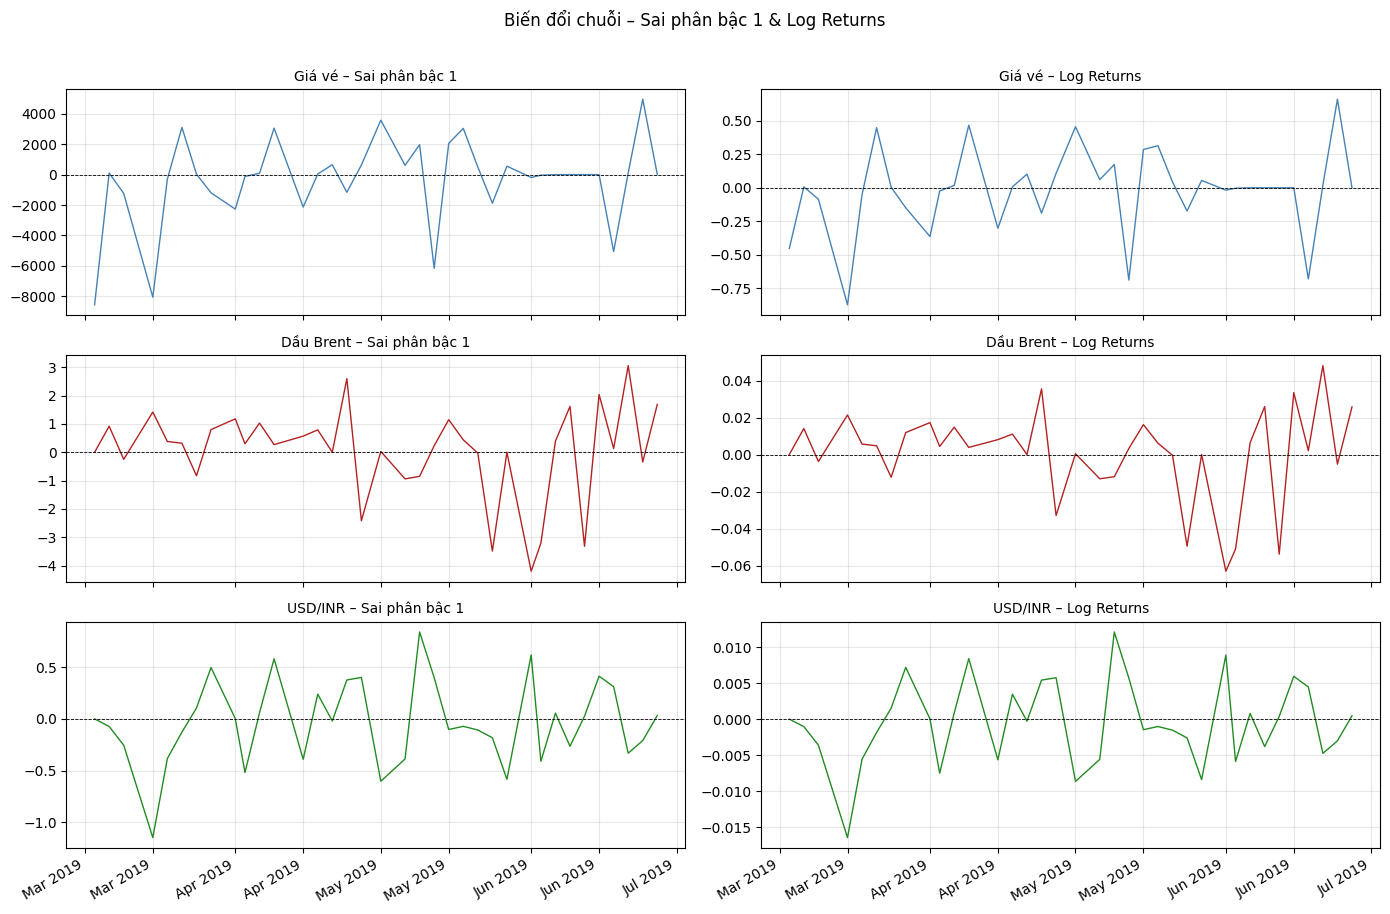

Đã lưu biểu đồ: eda_transformed.png


In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
vars_info = [
    ("Median_Price",       "Giá vé",   "steelblue"),
    ("Brent_Oil_Price",    "Dầu Brent", "firebrick"),
    ("USD_INR_Exchange",   "USD/INR",   "forestgreen"),
]

for i, (col, label, color) in enumerate(vars_info):
    axes[i][0].plot(df["Date"], df[f"{col}_diff"], color=color, linewidth=1)
    axes[i][0].axhline(0, color="black", linewidth=0.6, linestyle="--")
    axes[i][0].set_title(f"{label} – Sai phân bậc 1", fontsize=10)
    axes[i][0].grid(True, alpha=0.3)

    axes[i][1].plot(df["Date"], df[f"{col}_logret"], color=color, linewidth=1)
    axes[i][1].axhline(0, color="black", linewidth=0.6, linestyle="--")
    axes[i][1].set_title(f"{label} – Log Returns", fontsize=10)
    axes[i][1].grid(True, alpha=0.3)

axes[-1][0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1][1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
plt.suptitle("Biến đổi chuỗi – Sai phân bậc 1 & Log Returns", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("eda_transformed.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu biểu đồ: eda_transformed.png")

## 6. Lưu DataFrame đã xử lý

In [8]:
df.to_csv("master_data_merged.csv", index=False)
print(f"Đã cập nhật master_data_merged.csv ({df.shape[0]} dòng, {df.shape[1]} cột)")
print(df.dtypes)

Đã cập nhật master_data_merged.csv (37 dòng, 10 cột)
Date                       datetime64[ns]
Median_Price                      float64
Brent_Oil_Price                   float64
USD_INR_Exchange                  float64
Median_Price_diff                 float64
Median_Price_logret               float64
Brent_Oil_Price_diff              float64
Brent_Oil_Price_logret            float64
USD_INR_Exchange_diff             float64
USD_INR_Exchange_logret           float64
dtype: object
